In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/house_price_prediction/01_dataset/house_prices_linear_regression.csv')

In [ ]:
df.head(10)

,area_sqft,price
0,513,127753
1,516,103001
2,518,168105
3,524,124119
4,534,176296
5,544,139585
6,544,122826
7,548,136833
8,554,90938
9,555,146701


In [ ]:
df.shape

(500, 2)

In [ ]:
x_train = df["area_sqft"]
y_train = df["price"]
print(len(x_train))
print(len(y_train))

500
500


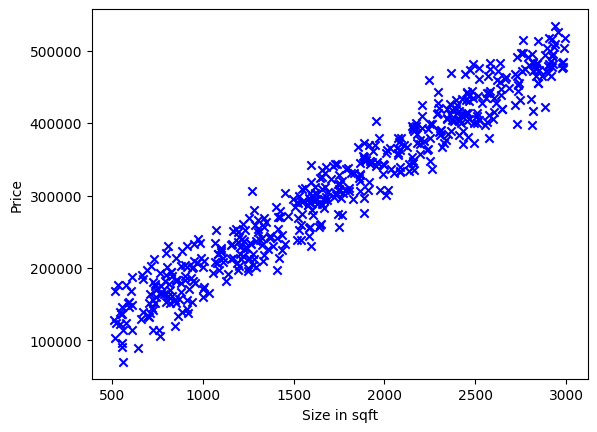

In [ ]:

plt.scatter(x_train, y_train, marker = 'x', c = 'b')
plt.xlabel("Size in sqft")
plt.ylabel("Price")
plt.show()

In [ ]:
df.min()

,0
area_sqft,513
price,70181


In [ ]:
df.max()

,0
area_sqft,2996
price,534217


In [ ]:
df.isnull()

,area_sqft,price
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
495,False,False
496,False,False
497,False,False
498,False,False


In [ ]:
print(df['area_sqft'].mean())
print(df['price'].mean())

1747.946
311080.878


**Linear Regression**

In [ ]:
def lin_reg(x,w,b):
  m = x.shape[0]
  f_wb = np.zeros(m)
  for i in range(m):
    f_wb[i] = w * x[i] + b
  return f_wb

In [ ]:
w = 50
b = 190

In [ ]:
apply_lin_reg = lin_reg(x_train, w, b)
print(apply_lin_reg[:10])

[25840. 25990. 26090. 26390. 26890. 27390. 27390. 27590. 27890. 27940.]


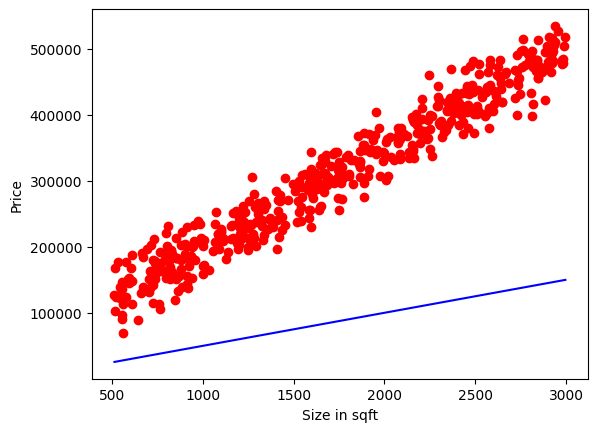

In [ ]:
plt.plot(x_train, apply_lin_reg, c='b', label= 'Model Prediction')
plt.scatter(x_train, y_train, c='r' , label ="Actual Values")
plt.xlabel("Size in sqft")
plt.ylabel("Price")
plt.show()

**Compute Cost using Mean Squared Error**

In [ ]:
# J(w,b) = 1/2m * (f_wb - y^i)^2

def compute_cost(x , y, w, b):
  m = x.shape[0]
  total_cost = 0
  for i in range(m):
    f_wb = w * x[i] + b
    cost = (f_wb - y[i]) ** 2
    total_cost += cost
  total_cost = total_cost/(2 * m)
  return total_cost


In [ ]:
print(compute_cost(x_train, y_train, w, b))

27888948363.091


In [ ]:
def compute_gradient(x,y,w,b):
  dj_dw = 0
  dj_db = 0
  j_wb_history = []
  w_b_history = []

  m = x.shape[0]
  for i in range(m):
    f_wb = w * x[i] + b
    dj_dw_i = (f_wb - y[i]) * x[i]
    dj_db_i = f_wb - y[i]

    dj_dw += dj_dw_i
    dj_db += dj_db_i

  dj_dw = dj_dw /  m
  dj_db = dj_db / m

  return dj_dw , dj_db


In [ ]:
def gradient_descent(x, y, w, b, alpha, num_iterations, compute_gradient_function, compute_cost_function):

  wb_history = []
  jw_history = []


  for i in range(num_iterations):

    dj_dw , dj_db = compute_gradient_function(x,y,w,b)


    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    if i < 10000:
      jw_history.append(compute_cost_function(x,y,w,b))
      wb_history.append([w,b])

    if i % math.ceil(num_iterations/5) == 0:
      print(f"Iterations: {i:4}, Cost: {jw_history[-1]:.2e}",
            f"dj_dw: {dj_dw:.3e}, dj_db: {dj_db:.3e}",
            f"w: {w:.3e}, b: {b:.5e}"

            )


  return wb_history, jw_history, w, b


In [ ]:
w_in = 100
b_in = 1000
alpha = 1e-8
num_iters = 50000
parameters_history, cost_history, w_final , b_final = gradient_descent(x_train, y_train, w_in, b_in, alpha, num_iters, compute_gradient, compute_cost)
print(dj_dw, dj_db, w_final, b_final)

Iterations:    0, Cost: 9.46e+09 dj_dw: -2.624e+08, dj_db: -1.353e+05 w: 1.026e+02, b: 1.00000e+03
Iterations: 10000, Cost: 4.81e+08 dj_dw: 3.270e+00, dj_db: -6.671e+03 w: 1.736e+02, b: 1.00070e+03
Iterations: 20000, Cost: 4.81e+08 dj_dw: 3.270e+00, dj_db: -6.671e+03 w: 1.736e+02, b: 1.00137e+03
Iterations: 30000, Cost: 4.81e+08 dj_dw: 3.270e+00, dj_db: -6.671e+03 w: 1.736e+02, b: 1.00204e+03
Iterations: 40000, Cost: 4.81e+08 dj_dw: 3.270e+00, dj_db: -6.671e+03 w: 1.736e+02, b: 1.00270e+03
3.2702443899922073 -6671.023745641751 173.5788648861732 1003.3717015794929


In [ ]:
# w = 15641441.200002031
# b = 15554043.899998367
prediction = lin_reg(x_train, w_final, b_final)


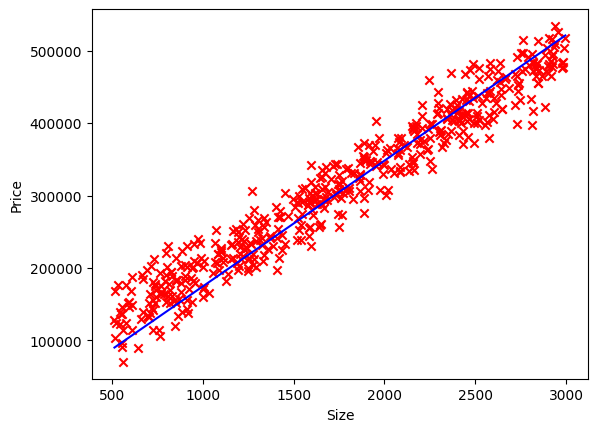

In [ ]:
plt.plot(x_train, prediction, c = 'b', label = "Model Prediction")
plt.scatter(x_train, y_train, c='r' , marker = 'x', label = "Actual VAlues")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

In [ ]:
new_cost = compute_cost(x_train, y_train, w_final, b_final)
print(new_cost)

480560764.207283


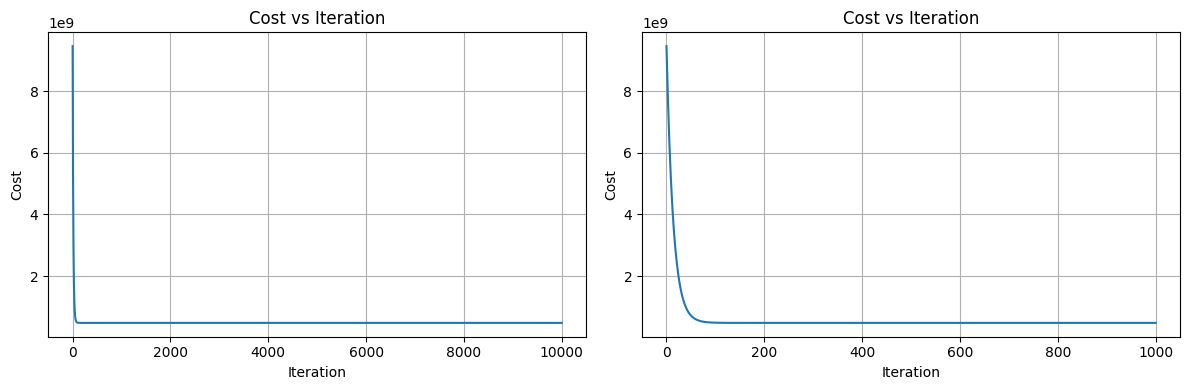

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(cost_history[:1000])
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.grid(True)

plt.tight_layout()
plt.show()